# Wet Area Analysis and Visualization

This notebook loads the wet-area summary pickle produced by `rainfall_coverage_finder.ipynb`, 
computes summary statistics, and generates visualizations to compare historical vs future scenarios.


What you'll get:
- Automatic detection of the latest `wet_area_summary_*.pkl` (or set a specific threshold).
- Flattened columns for easy analysis.
- Distributions, scatter plots, and aggregated trends vs distance `d`.
- A small summary table and an optional CSV export.

In [1]:
# Imports and setup
import os, glob
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Robust styling across versions
try:
    sns.set_theme(context='talk', style='whitegrid')
except Exception:
    pass

# Paths
sim_dir = r"D:/Development/RESEARCH/Raanana/SWMM/from_radar/Climate_Change"
pickles_dir = os.path.join(sim_dir, 'pickles')

# Choose threshold to load; set to a number to force a specific file, or None to auto-pick the latest
RAIN_THRESHOLD = None  # e.g., 25 or 1; None => pick the most recent matching file

def threshold_to_name(val):
    if isinstance(val, (int, np.integer)):
        return str(int(val))
    if isinstance(val, float) and float(val).is_integer():
        return str(int(val))
    return str(val)

if RAIN_THRESHOLD is not None:
    candidate = os.path.join(pickles_dir, f"wet_area_summary_{threshold_to_name(RAIN_THRESHOLD)}.pkl")
    paths = [candidate] if os.path.exists(candidate) else []
else:
    paths = sorted(glob.glob(os.path.join(pickles_dir, 'wet_area_summary_*.pkl')), key=os.path.getmtime, reverse=True)

assert paths, 'No wet_area_summary_*.pkl found in pickles directory.'
pkl_path = paths[0]
print('Loading:', pkl_path)

Loading: D:/Development/RESEARCH/Raanana/SWMM/from_radar/Climate_Change\pickles\wet_area_summary_10.pkl


In [2]:
# Load the DataFrame
df = pd.read_pickle(pkl_path)
print('Shape:', df.shape)
df.head(3)

Shape: (3321, 8)


event_num  x      y        d            historical                       \
                                        spatial_rain                        
                               wet_area_percent_mean wet_area_percent_max   
0        01  0 -20000  20000.0              0.697210                100.0   
1        01  0 -19500  19500.0              0.708502                100.0   
2        01  0 -19000  19000.0              0.709853                100.0   

                 future                       
           spatial_rain                       
  wet_area_percent_mean wet_area_percent_max  
0              1.327717                100.0  
1              1.245266                100.0  
2              1.195500                100.0

In [3]:
# Flatten columns (handles MultiIndex columns from the merge)
def flatten_columns(df):
    if isinstance(df.columns, pd.MultiIndex):
        new_cols = ['.'.join([str(x) for x in tup if str(x) != '']) for tup in df.columns.to_list()]
        df = df.copy()
        df.columns = new_cols
    else:
        df = df.copy()
        df.columns = [str(c) for c in df.columns]
    return df

flat = flatten_columns(df)
print('Flattened columns (sample):', list(flat.columns)[:10])
flat.head(3)

Flattened columns (sample): ['event_num', 'x', 'y', 'd', 'historical.spatial_rain.wet_area_percent_mean', 'historical.spatial_rain.wet_area_percent_max', 'future.spatial_rain.wet_area_percent_mean', 'future.spatial_rain.wet_area_percent_max']


,event_num,x,y,d,historical.spatial_rain.wet_area_percent_mean,historical.spatial_rain.wet_area_percent_max,future.spatial_rain.wet_area_percent_mean,future.spatial_rain.wet_area_percent_max
0,01,0,-20000,20000.0,0.697210,100.0,1.327717,100.0
1,01,0,-19500,19500.0,0.708502,100.0,1.245266,100.0
2,01,0,-19000,19000.0,0.709853,100.0,1.195500,100.0


In [4]:
# Build a tidy DataFrame with core columns and metrics
base_cols = ['event_num', 'x', 'y', 'd']
metrics = {
    'h_mean': 'historical.spatial_rain.wet_area_percent_mean',
    'h_max':  'historical.spatial_rain.wet_area_percent_max',
    'f_mean': 'future.spatial_rain.wet_area_percent_mean',
    'f_max':  'future.spatial_rain.wet_area_percent_max',
}

def safe_get(col):
    return flat[col] if col in flat.columns else None

def safe_sub(a, b):
    if a is None or b is None:
        return pd.Series(np.nan, index=flat.index)
    return a - b

use_cols = [c for c in base_cols if c in flat.columns] + [c for c in metrics.values() if c in flat.columns]
data = flat[use_cols].copy()

# Ensure numeric types
for c in ['x', 'y', 'd']:
    if c in data.columns:
        data[c] = pd.to_numeric(data[c], errors='coerce')

data['delta.mean'] = safe_sub(safe_get(metrics['f_mean']), safe_get(metrics['h_mean']))
data['delta.max']  = safe_sub(safe_get(metrics['f_max']),  safe_get(metrics['h_max']))

print('Data columns:', list(data.columns))
data.head(3)

Data columns: ['event_num', 'x', 'y', 'd', 'historical.spatial_rain.wet_area_percent_mean', 'historical.spatial_rain.wet_area_percent_max', 'future.spatial_rain.wet_area_percent_mean', 'future.spatial_rain.wet_area_percent_max', 'delta.mean', 'delta.max']


,event_num,x,y,d,historical.spatial_rain.wet_area_percent_mean,historical.spatial_rain.wet_area_percent_max,future.spatial_rain.wet_area_percent_mean,future.spatial_rain.wet_area_percent_max,delta.mean,delta.max
0,01,0,-20000,20000.0,0.697210,100.0,1.327717,100.0,0.630507,0.0
1,01,0,-19500,19500.0,0.708502,100.0,1.245266,100.0,0.536765,0.0
2,01,0,-19000,19000.0,0.709853,100.0,1.195500,100.0,0.485647,0.0


In [5]:
# Quick summary stats
summary = {}
for key, col in metrics.items():
    if col in data.columns:
        s = data[col].astype(float)
        summary[col] = dict(
            count=int(s.count()),
            mean=float(s.mean()),
            std=float(s.std(ddof=1) if s.count() > 1 else np.nan),
            min=float(s.min()),
            q25=float(s.quantile(0.25)),
            median=float(s.median()),
            q75=float(s.quantile(0.75)),
            max=float(s.max()),
        )
# Add deltas if present
for dcol in ['delta.mean', 'delta.max']:
    if dcol in data.columns:
        s = data[dcol].astype(float)
        summary[dcol] = dict(
            count=int(s.count()),
            mean=float(s.mean()),
            std=float(s.std(ddof=1) if s.count() > 1 else np.nan),
            min=float(s.min()),
            q25=float(s.quantile(0.25)),
            median=float(s.median()),
            q75=float(s.quantile(0.75)),
            max=float(s.max()),
        )
summary_df = pd.DataFrame(summary).T
summary_df

,count,mean,std,min,q25,median,q75,max
historical.spatial_rain.wet_area_percent_mean,3321.0,0.984094,0.958911,0.000000,0.215478,0.768492,1.423287,5.516891
historical.spatial_rain.wet_area_percent_max,3321.0,71.014320,38.048924,0.000000,44.711829,95.873567,100.000000,100.000000
future.spatial_rain.wet_area_percent_mean,3321.0,0.939238,0.981828,0.000000,0.084515,0.748794,1.449704,5.822321
future.spatial_rain.wet_area_percent_max,3321.0,66.684843,41.490060,0.000000,22.337055,94.726916,100.000000,100.000000
delta.mean,3321.0,-0.044857,0.730230,-2.484289,-0.402296,0.000000,0.358513,3.577456
delta.max,3321.0,-4.329476,31.956924,-100.000000,-8.916717,0.000000,0.000000,100.000000


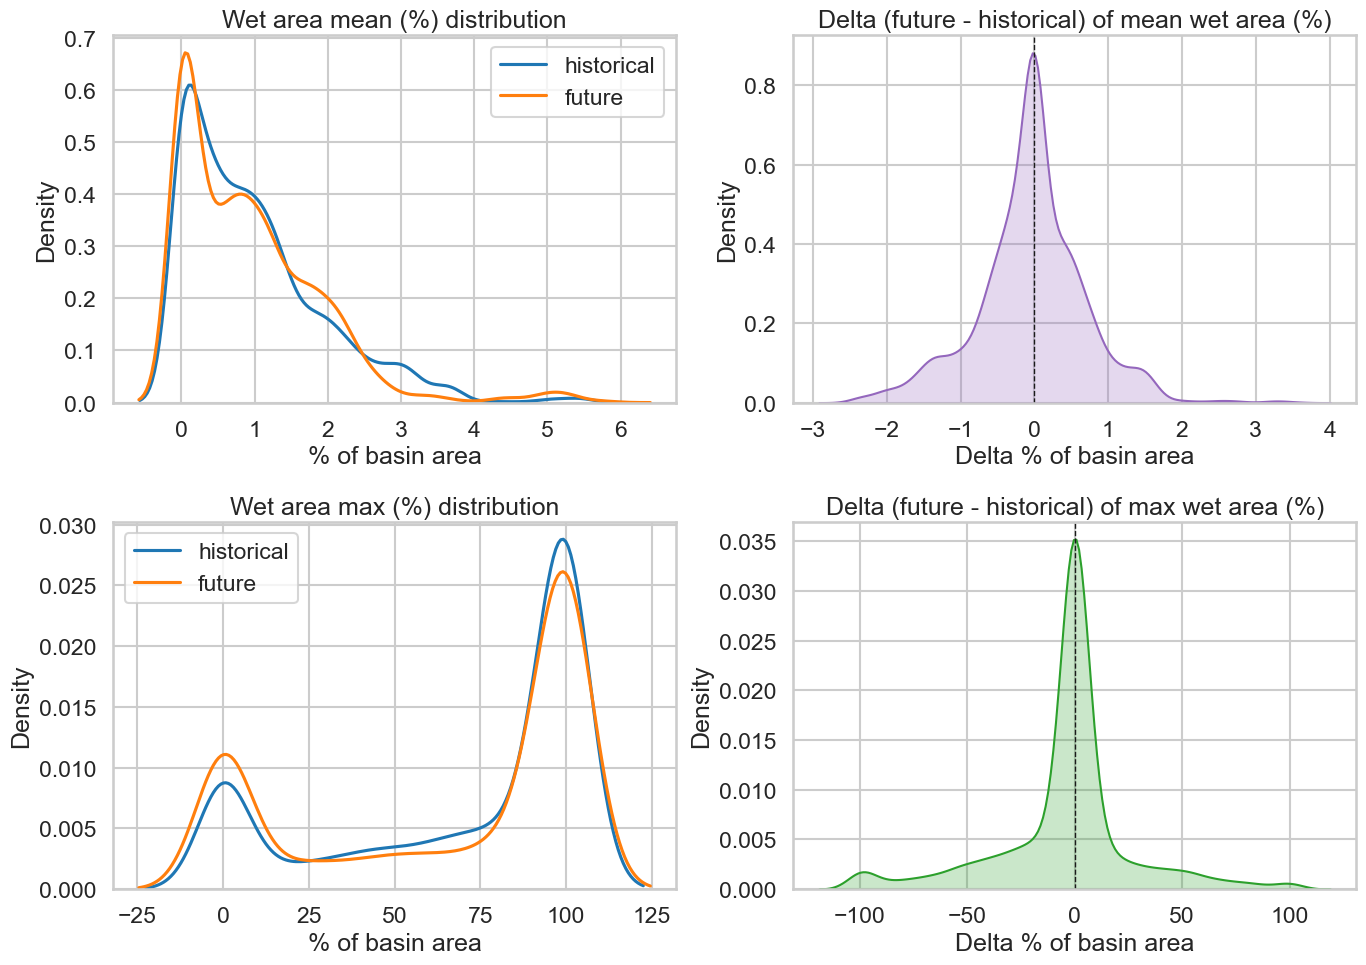

In [6]:
# Distribution of mean and max wet area: historical vs future
fig, ax = plt.subplots(2, 2, figsize=(14, 10))
# Mean
if metrics['h_mean'] in data.columns:
    sns.kdeplot(data=data, x=metrics['h_mean'], label='historical', ax=ax[0,0], color='#1f77b4')
if metrics['f_mean'] in data.columns:
    sns.kdeplot(data=data, x=metrics['f_mean'], label='future', ax=ax[0,0], color='#ff7f0e')
ax[0,0].legend()
ax[0,0].set_title('Wet area mean (%) distribution')
ax[0,0].set_xlabel('% of basin area')

sns.kdeplot(data=data, x='delta.mean', fill=True, ax=ax[0,1], color='#9467bd')
ax[0,1].axvline(0, color='k', ls='--', lw=1)
ax[0,1].set_title('Delta (future - historical) of mean wet area (%)')
ax[0,1].set_xlabel('Delta % of basin area')

# Max
if metrics['h_max'] in data.columns:
    sns.kdeplot(data=data, x=metrics['h_max'], label='historical', ax=ax[1,0], color='#1f77b4')
if metrics['f_max'] in data.columns:
    sns.kdeplot(data=data, x=metrics['f_max'], label='future', ax=ax[1,0], color='#ff7f0e')
ax[1,0].legend()
ax[1,0].set_title('Wet area max (%) distribution')
ax[1,0].set_xlabel('% of basin area')

if 'delta.max' in data.columns:
    sns.kdeplot(data=data, x='delta.max', fill=True, ax=ax[1,1], color='#2ca02c')
    ax[1,1].axvline(0, color='k', ls='--', lw=1)
    ax[1,1].set_title('Delta (future - historical) of max wet area (%)')
    ax[1,1].set_xlabel('Delta % of basin area')

plt.tight_layout()
plt.show()

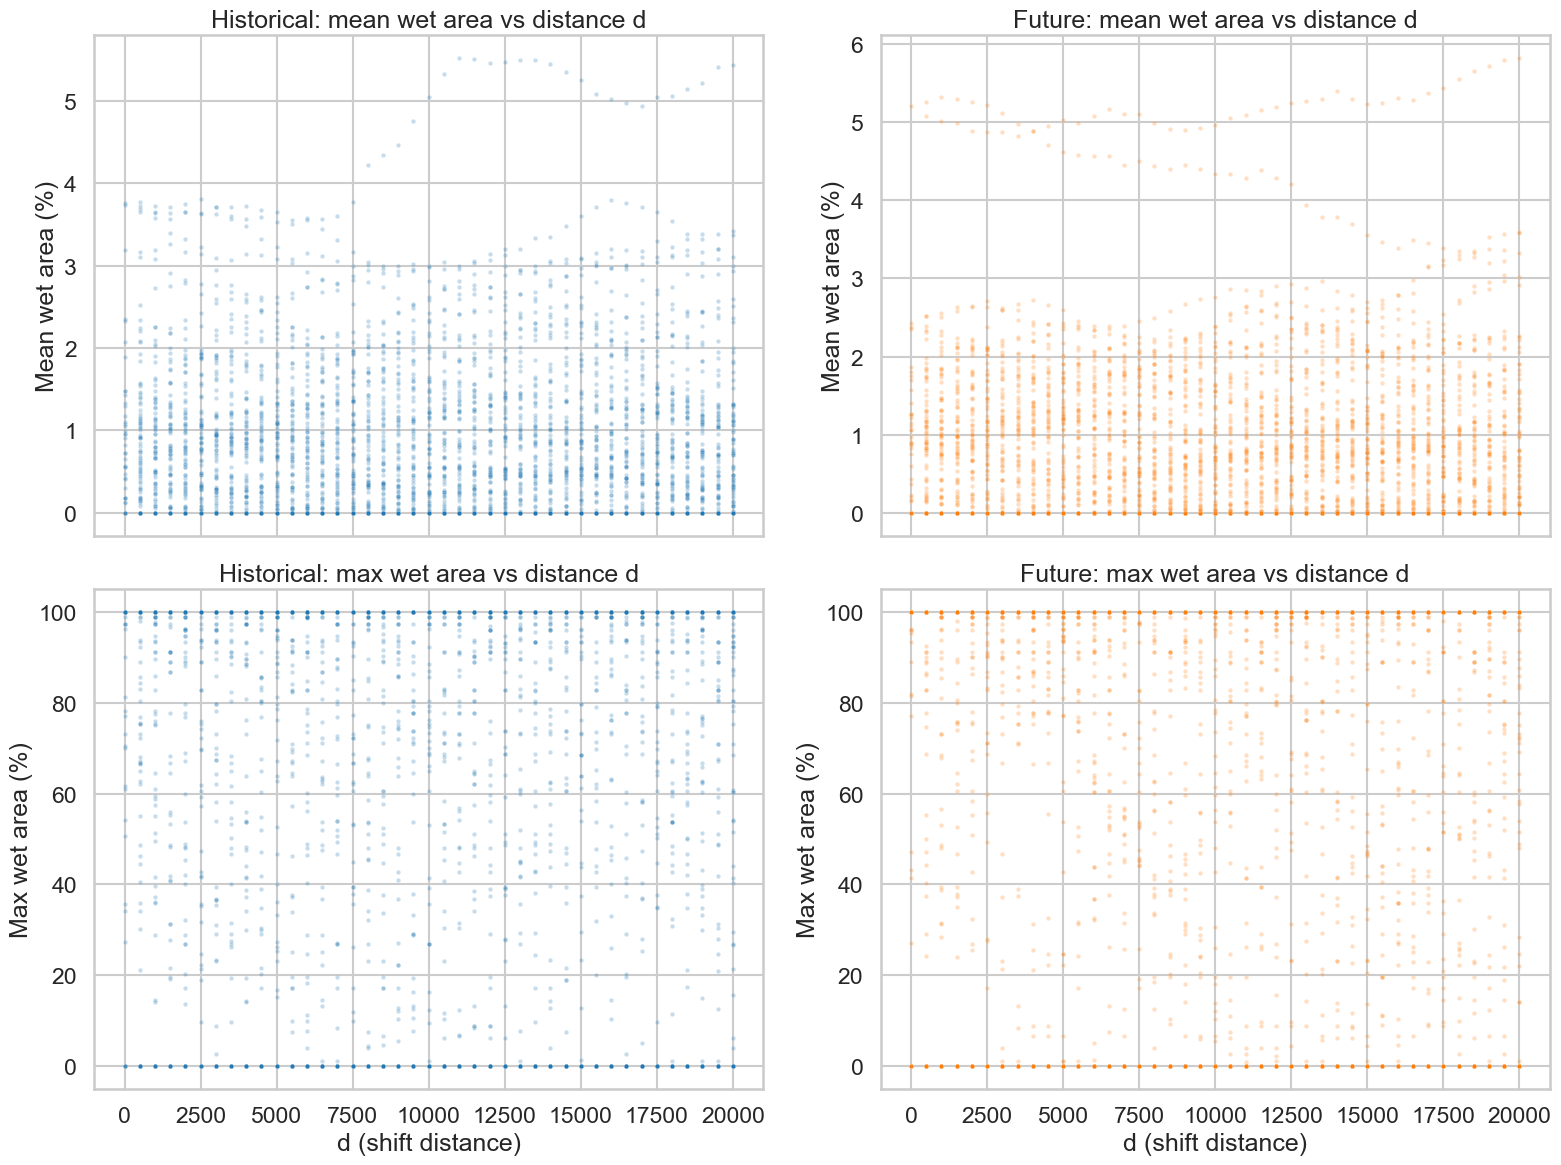

In [7]:
# Scatter: distance vs mean and max wet area for each scenario
fig, ax = plt.subplots(2, 2, figsize=(16, 12), sharex=True, sharey=False)

# Mean
if 'd' in data.columns and metrics['h_mean'] in data.columns:
    sns.scatterplot(data=data, x='d', y=metrics['h_mean'], s=10, alpha=0.25, ax=ax[0,0], color='#1f77b4')
    ax[0,0].set_title('Historical: mean wet area vs distance d')
    ax[0,0].set_xlabel('d (shift distance)')
    ax[0,0].set_ylabel('Mean wet area (%)')
if 'd' in data.columns and metrics['f_mean'] in data.columns:
    sns.scatterplot(data=data, x='d', y=metrics['f_mean'], s=10, alpha=0.25, ax=ax[0,1], color='#ff7f0e')
    ax[0,1].set_title('Future: mean wet area vs distance d')
    ax[0,1].set_xlabel('d (shift distance)')
    ax[0,1].set_ylabel('Mean wet area (%)')

# Max
if 'd' in data.columns and metrics['h_max'] in data.columns:
    sns.scatterplot(data=data, x='d', y=metrics['h_max'], s=10, alpha=0.25, ax=ax[1,0], color='#1f77b4')
    ax[1,0].set_title('Historical: max wet area vs distance d')
    ax[1,0].set_xlabel('d (shift distance)')
    ax[1,0].set_ylabel('Max wet area (%)')
if 'd' in data.columns and metrics['f_max'] in data.columns:
    sns.scatterplot(data=data, x='d', y=metrics['f_max'], s=10, alpha=0.25, ax=ax[1,1], color='#ff7f0e')
    ax[1,1].set_title('Future: max wet area vs distance d')
    ax[1,1].set_xlabel('d (shift distance)')
    ax[1,1].set_ylabel('Max wet area (%)')

plt.tight_layout()
plt.show()

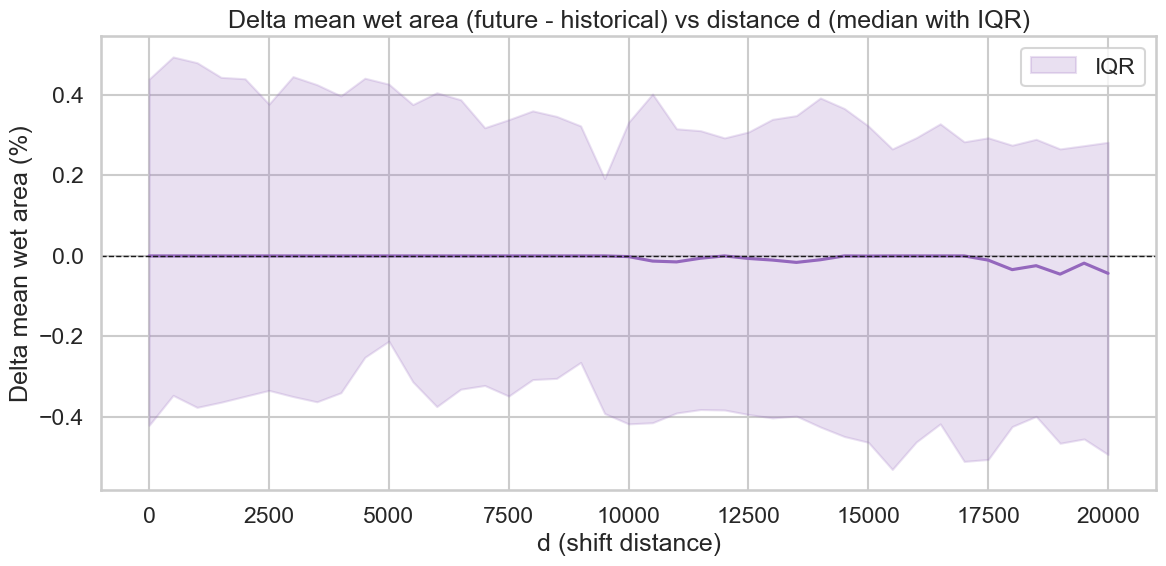

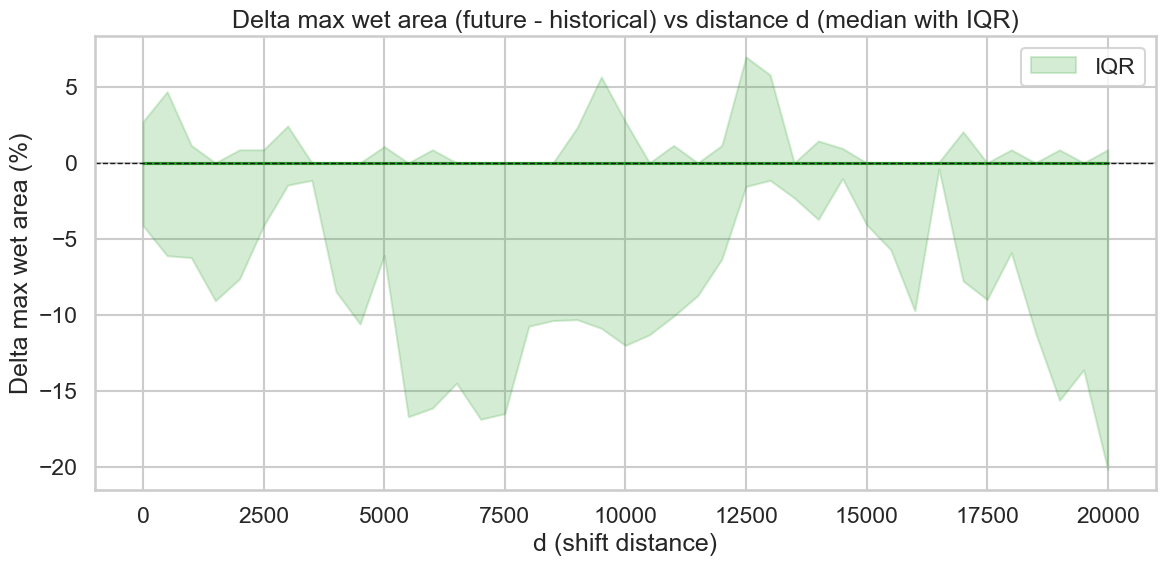

In [8]:
# Aggregate delta by distance: median and IQR for mean and max
if 'd' in data.columns:
    # Mean delta aggregation
    agg_mean = data.groupby('d', as_index=False).agg(
        delta_mean_median=('delta.mean', 'median'),
        delta_mean_q25=('delta.mean', lambda s: s.quantile(0.25)),
        delta_mean_q75=('delta.mean', lambda s: s.quantile(0.75))
    )
    fig, ax = plt.subplots(figsize=(12, 6))
    sns.lineplot(data=agg_mean, x='d', y='delta_mean_median', ax=ax, color='#9467bd')
    ax.fill_between(agg_mean['d'], agg_mean['delta_mean_q25'], agg_mean['delta_mean_q75'], color='#9467bd', alpha=0.2, label='IQR')
    ax.axhline(0, color='k', ls='--', lw=1)
    ax.set_title('Delta mean wet area (future - historical) vs distance d (median with IQR)')
    ax.set_xlabel('d (shift distance)')
    ax.set_ylabel('Delta mean wet area (%)')
    ax.legend()
    plt.tight_layout()
    plt.show()
    agg_mean.head(10)

    # Max delta aggregation (if available)
    if 'delta.max' in data.columns:
        agg_max = data.groupby('d', as_index=False).agg(
            delta_max_median=('delta.max', 'median'),
            delta_max_q25=('delta.max', lambda s: s.quantile(0.25)),
            delta_max_q75=('delta.max', lambda s: s.quantile(0.75))
        )
        fig, ax = plt.subplots(figsize=(12, 6))
        sns.lineplot(data=agg_max, x='d', y='delta_max_median', ax=ax, color='#2ca02c')
        ax.fill_between(agg_max['d'], agg_max['delta_max_q25'], agg_max['delta_max_q75'], color='#2ca02c', alpha=0.2, label='IQR')
        ax.axhline(0, color='k', ls='--', lw=1)
        ax.set_title('Delta max wet area (future - historical) vs distance d (median with IQR)')
        ax.set_xlabel('d (shift distance)')
        ax.set_ylabel('Delta max wet area (%)')
        ax.legend()
        plt.tight_layout()
        plt.show()
        agg_max.head(10)

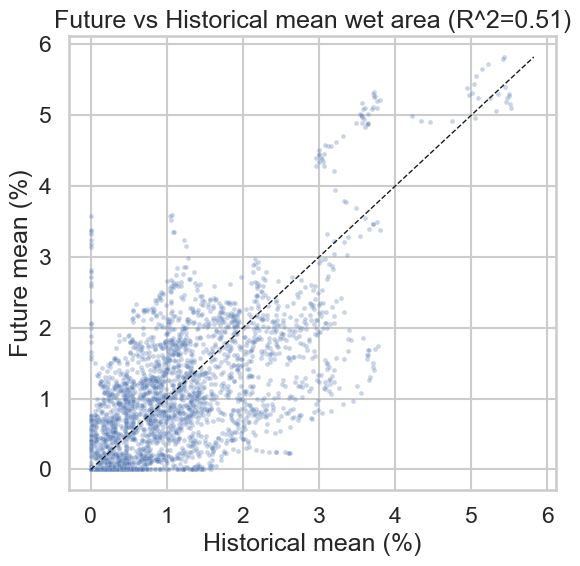

In [9]:
# Scatter: historical vs future mean wet area with 1:1 line
if all(col in data.columns for col in (metrics['h_mean'], metrics['f_mean'])):
    tmp = data[[metrics['h_mean'], metrics['f_mean']]].dropna()
    r = np.corrcoef(tmp[metrics['h_mean']], tmp[metrics['f_mean']])[0, 1] if len(tmp) > 1 else np.nan
    r2 = r ** 2 if pd.notna(r) else np.nan
    fig, ax = plt.subplots(figsize=(6, 6))
    sns.scatterplot(x=metrics['h_mean'], y=metrics['f_mean'], data=tmp, s=12, alpha=0.3, ax=ax)
    mn = float(min(tmp.min()))
    mx = float(max(tmp.max()))
    ax.plot([mn, mx], [mn, mx], 'k--', lw=1)
    ax.set_title(f'Future vs Historical mean wet area (R^2={r2:.2f})')
    ax.set_xlabel('Historical mean (%)')
    ax.set_ylabel('Future mean (%)')
    plt.tight_layout()
    plt.show()